In [1]:
num_servers = 2988
num_racks = 80
seed = 1
loaddict = {"unv1":9,"prv1":8} # {"unv1":9,"prv1":8,"cluster_a":24,"cluster_b":32,"cluster_c":30}
scheme_list = ["leafspine","dringsu2","dringsu3","dringecmp","dringfatpaths","dringfhi","dringracke1","df2augalg","rrgsu2","rrgsu3"]

Plotting CDF for unv1 leafspine
Plotting CDF for unv1 dringsu2
Plotting CDF for unv1 dringsu3
Plotting CDF for unv1 dringecmp
Plotting CDF for unv1 dringfatpaths
Plotting CDF for unv1 dringfhi
Plotting CDF for unv1 dringracke1
Plotting CDF for unv1 df2augalg
Plotting CDF for unv1 rrgsu2
Plotting CDF for unv1 rrgsu3
Plotting CDF for prv1 leafspine
Plotting CDF for prv1 dringsu2
Plotting CDF for prv1 dringsu3
Plotting CDF for prv1 dringecmp
Plotting CDF for prv1 dringfatpaths
Plotting CDF for prv1 dringfhi
Plotting CDF for prv1 dringracke1
Plotting CDF for prv1 df2augalg
Plotting CDF for prv1 rrgsu2
Plotting CDF for prv1 rrgsu3


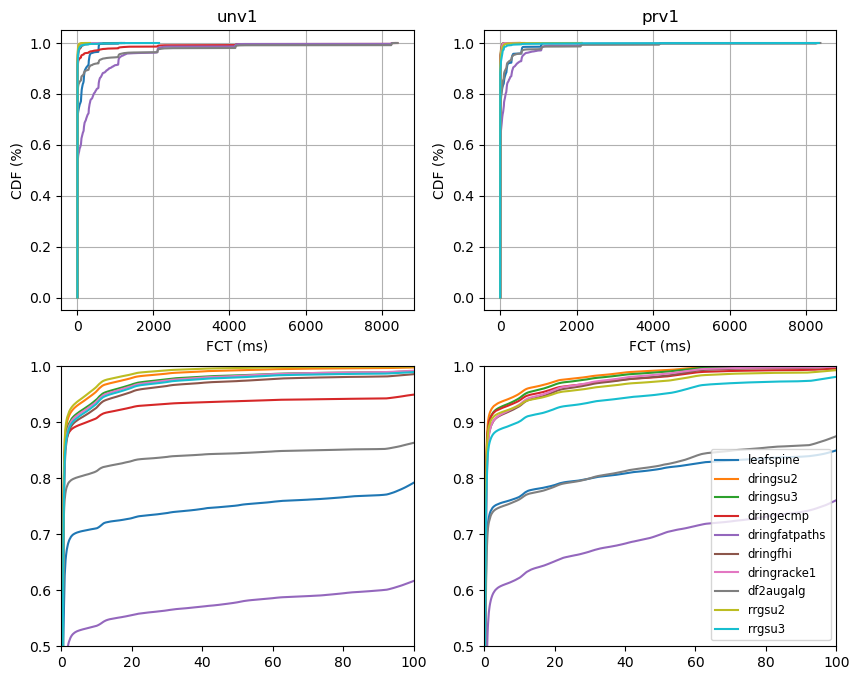

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

nr = 2
nc = len(loaddict)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
ic = 0
for cm,load in loaddict.items():
    datadict = dict()
    with open(f'../../../../../../../az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_{cm}.pickle', "rb") as f:
        datadict = pickle.load(f)
    for scheme in scheme_list:
        print(f"Plotting CDF for {cm} {scheme}")
        outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out" # name in dict, not actually file path
        fctlist = datadict[outfile][0]
        fctlist_sorted = np.sort(fctlist)
        cdf = np.arange(1, len(fctlist_sorted)+1) / len(fctlist_sorted)
        axs[0,ic].plot(fctlist_sorted, cdf)
        axs[1,ic].plot(fctlist_sorted, cdf)
    axs[0,ic].set_xlabel("FCT (ms)")
    axs[0,ic].set_ylabel("CDF (%)")
    axs[0,ic].set_title(cm)
    axs[0,ic].grid(True)
    axs[1,ic].set_xlim(0,100)
    axs[1,ic].set_ylim(0.5,1)
    ic += 1
plt.legend(scheme_list, loc='lower right', fontsize='small')